In [1]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.green_gecko_model import CAModel, make_seed

from src.lyapunov import estimate_lyapunov_spectrum

# Visualization and Lyapunov of learning
### Config

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2-2, size//2-2
x_end, y_end = TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE # size//2+2, size//2+2

# Whether to scale the attractor or not
scale_attractor = True

folder = "model/plain_salamander/big_fire_rate1_nr3/"

### Plot burn in for all recorded models

2026-04-12 01:15:52.354185: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-12 01:15:52.354212: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-12 01:15:52.354219: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-12 01:15:52.354237: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 01:15:52.354250: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-12 01:15:52.730803: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


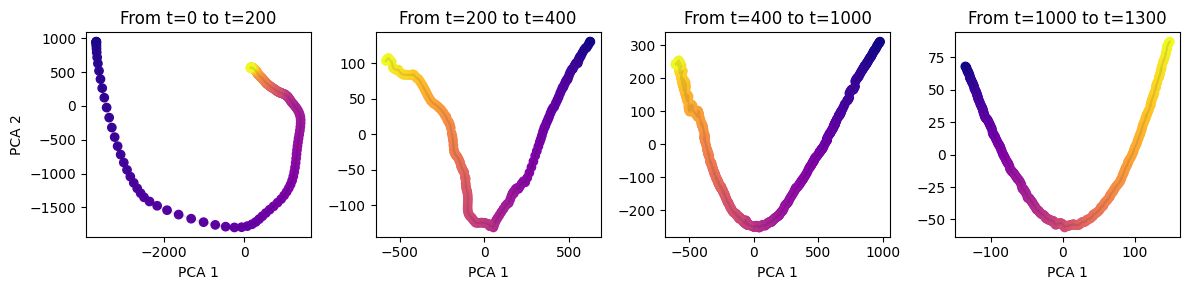

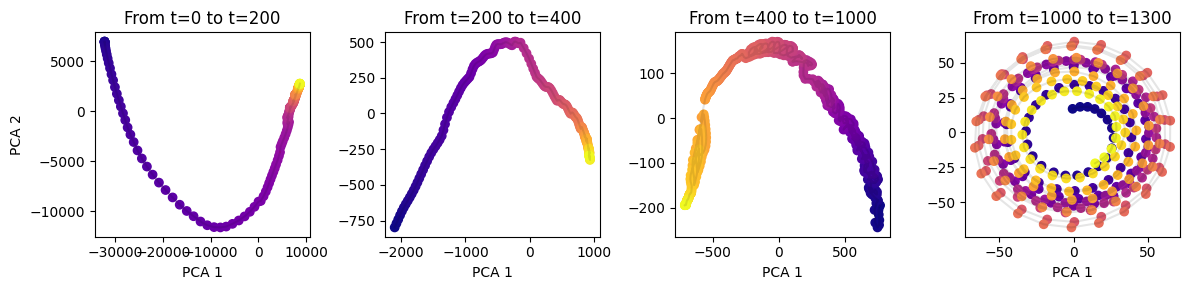

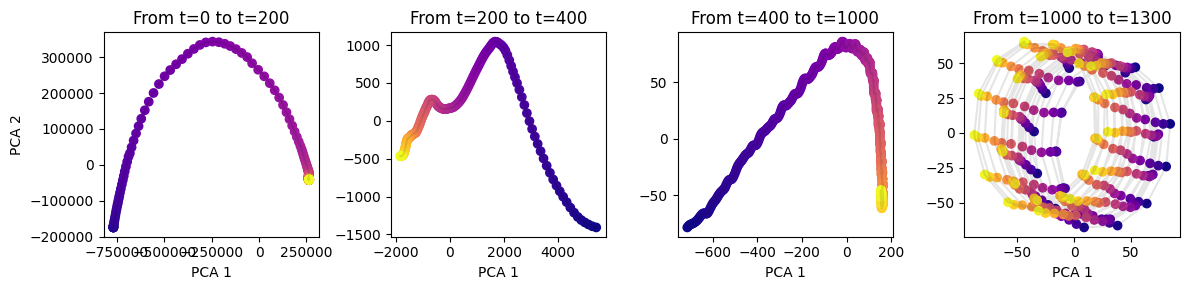

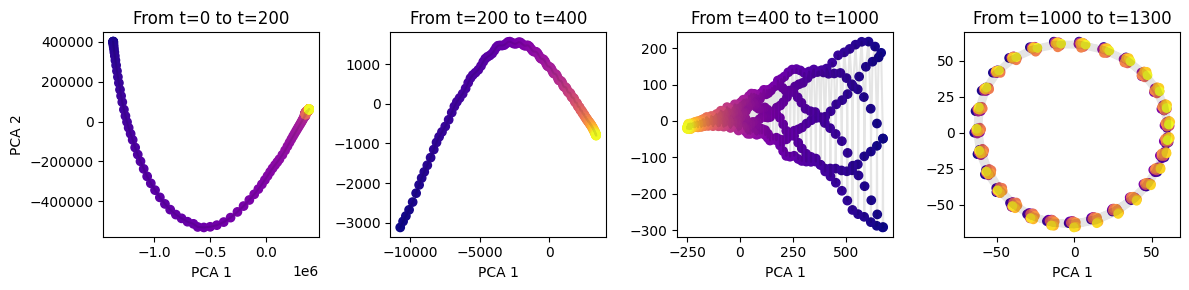

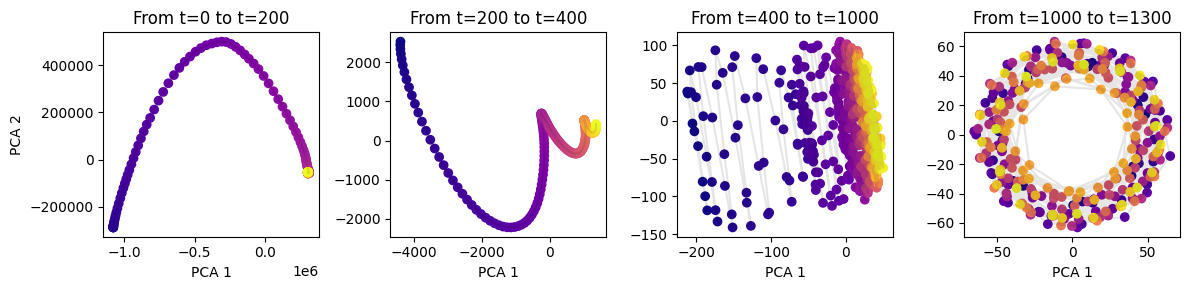

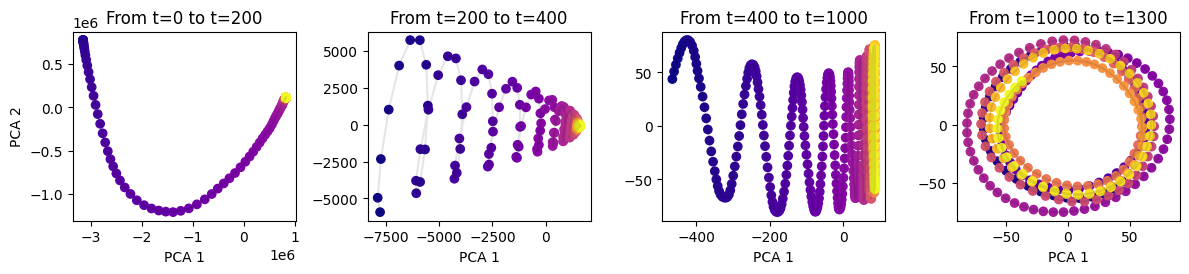

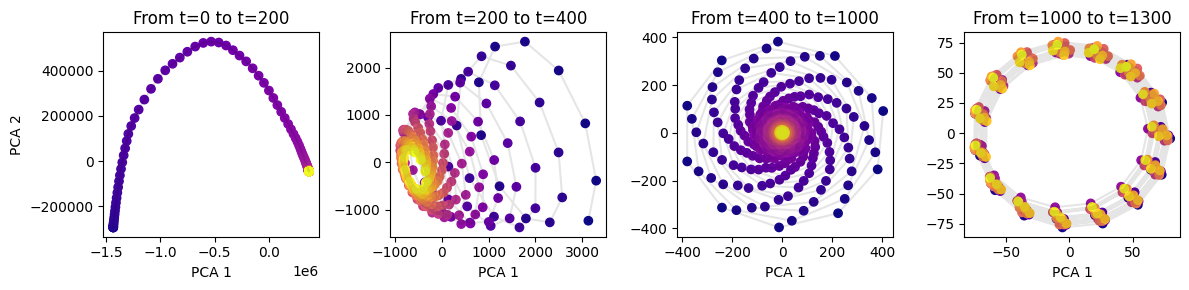

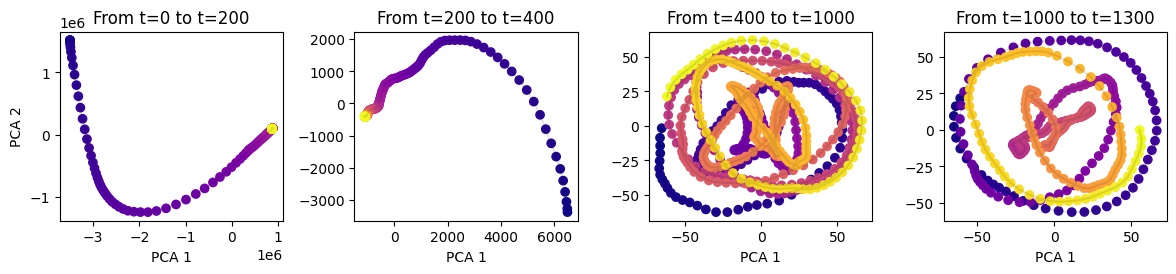

In [3]:
def load_model(i):
    model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
    model.load_weights(folder+f"{i}.weights.h5")
    return model

def run_model(model, steps):
    seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
    x = tf.convert_to_tensor(seed)

    states = [tf.identity(x).numpy()]

    for iter in range(steps):
        x = model(x)
        states.append(tf.identity(x).numpy())

    states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end]

    return states_np

def plot_falling_in(flattened_states, timesteps, high_light_step=60):
    plt.figure(figsize=(12,3))

    for i in range(len(timesteps)-1):
        t1, t2 = timesteps[i], timesteps[i+1]

        pca_states = PCA(n_components=2).fit_transform(flattened_states[t1:t2])

        plt.subplot(1, len(timesteps)-1, i+1)
        plt.title(f"From t={t1} to t={t2}")
        plt.scatter(pca_states[:, 0], pca_states[:, 1], c=np.arange(pca_states.shape[0])/pca_states.shape[0], cmap="plasma")
        plt.plot(pca_states[:, 0], pca_states[:, 1], 'k-', alpha=0.1)
        plt.xlabel("PCA 1")
        if i == 0:
            plt.ylabel("PCA 2")

        if t1 <= high_light_step <= t2:
            circle = plt.Circle((pca_states[high_light_step, 0], pca_states[high_light_step, 1]), 4, facecolor="#C3262600", edgecolor="#FF0000FF")
            plt.gca().add_patch(circle)

    plt.tight_layout()

def plot_attractor_burn_in(i):
    timesteps_plot = [0, 200, 400, 1000, 1300]

    states_np = run_model(load_model(i), steps=timesteps_plot[-1])

    flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)

    if scale_attractor:
        scaler = StandardScaler()
        scaler = scaler.fit(flattened_attractor_states[timesteps_plot[-2]:]) # originally 2000
        flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

    plot_falling_in(flattened_attractor_states if not scale_attractor else flattened_attractor_states_scaled, timesteps_plot)

for i in np.arange(1000, 9000, 1000):
    plot_attractor_burn_in(i)
    plt.show()

### Now, plot only the final attractor for each epoch, recorded model

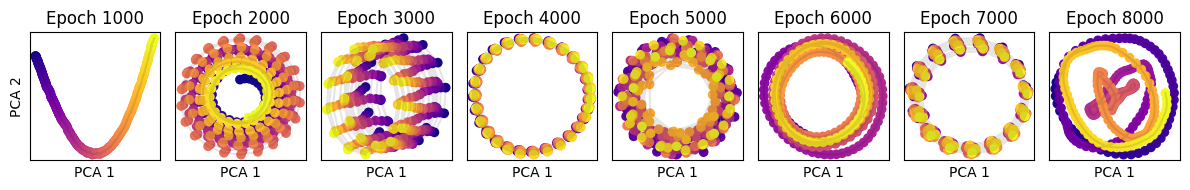

In [4]:
def load_model(i):
    model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
    model.load_weights(folder+f"{i}.weights.h5")
    return model

def run_model(model, steps):
    seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
    x = tf.convert_to_tensor(seed)

    states = [tf.identity(x).numpy()]

    for iter in range(steps):
        x = model(x)
        states.append(tf.identity(x).numpy())

    states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end]

    return states_np

start_t = 1000
end_t = 1300

plt.figure(figsize=(12,2))

for i in np.arange(1000, 9000, 1000):
    states_np = run_model(load_model(i), steps=end_t)
    flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)

    if scale_attractor:
        scaler = StandardScaler()
        scaler = scaler.fit(flattened_attractor_states[start_t:]) 
        flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

    pca = PCA(n_components=2)
    pca = pca.fit(flattened_attractor_states[start_t:] if not scale_attractor else flattened_attractor_states_scaled[start_t:])
    pca_states = pca.transform(flattened_attractor_states[start_t:] if not scale_attractor else flattened_attractor_states_scaled[start_t:])

    plt.subplot(1, 8, int(i/1000))
    plt.title(f"Epoch {i}")
    plt.scatter(pca_states[:, 0], pca_states[:, 1], c=np.arange(pca_states.shape[0])/pca_states.shape[0], cmap="plasma")
    plt.plot(pca_states[:, 0], pca_states[:, 1], 'k-', alpha=0.1)
    plt.xlabel("PCA 1")
    if i == 1000:
        plt.ylabel("PCA 2")

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

### Calculate Lyapunov exponents

In [6]:
start_t = 1000
end_t = 1300

tf.config.experimental.enable_op_determinism()

for i in np.arange(1000, 9000, 1000):
    tf.random.set_seed(0)
    tf.keras.utils.set_random_seed(0)

    model = load_model(i)
    states_np = run_model(model, steps=end_t)

    res, _ = estimate_lyapunov_spectrum(
        model, states_np[-1], k=1, steps=10000, epsilon=1e-4, 
        mode="finite_diff", ortho_mode="QR", init_mode="initializer", dynamic_epsilon=False, warm_up=100)

    print("Model", i, "Lyapunov exponent:", res)

100%|██████████| 10100/10100 [02:30<00:00, 67.14it/s]


Model 1000 Lyapunov exponent: tf.Tensor([0.00175851], shape=(1,), dtype=float64)


100%|██████████| 10100/10100 [02:44<00:00, 61.35it/s]


Model 2000 Lyapunov exponent: tf.Tensor([5.72117296e-05], shape=(1,), dtype=float64)


100%|██████████| 10100/10100 [02:45<00:00, 60.98it/s]


...

Model 6000 Lyapunov exponent: tf.Tensor([-0.00941079], shape=(1,), dtype=float64)


100%|██████████| 10100/10100 [02:45<00:00, 61.08it/s]


Model 7000 Lyapunov exponent: tf.Tensor([-0.00315593], shape=(1,), dtype=float64)


100%|██████████| 10100/10100 [02:37<00:00, 63.95it/s]

Model 8000 Lyapunov exponent: tf.Tensor([-0.0156527], shape=(1,), dtype=float64)


The final calculated value doesn't correspond with the one in the paper, but this is not unexpected to me. Although I tried to run it with the same seed, I had fewer exponents here, and this model was especially sensitive in calculation.